通过梯度下降法得到的参数 theta: [-3.63029144  1.16636235]
最终损失值: 4.483388256587725


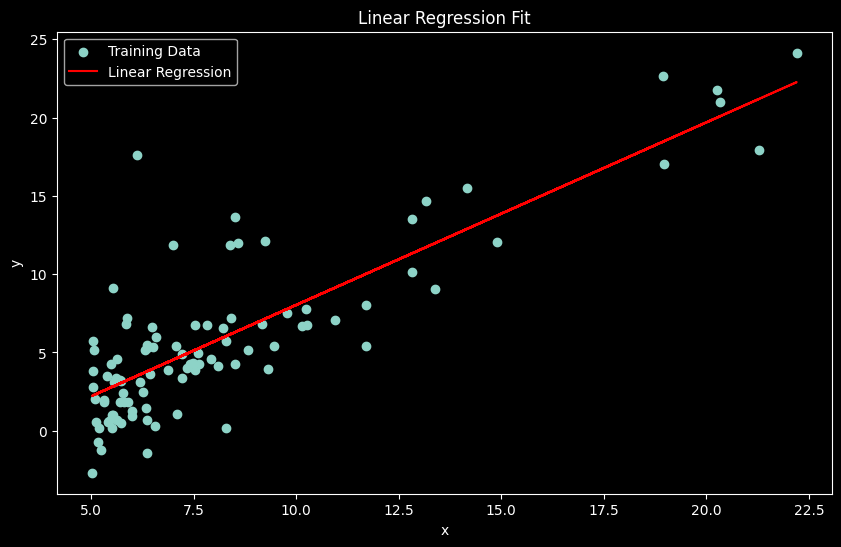

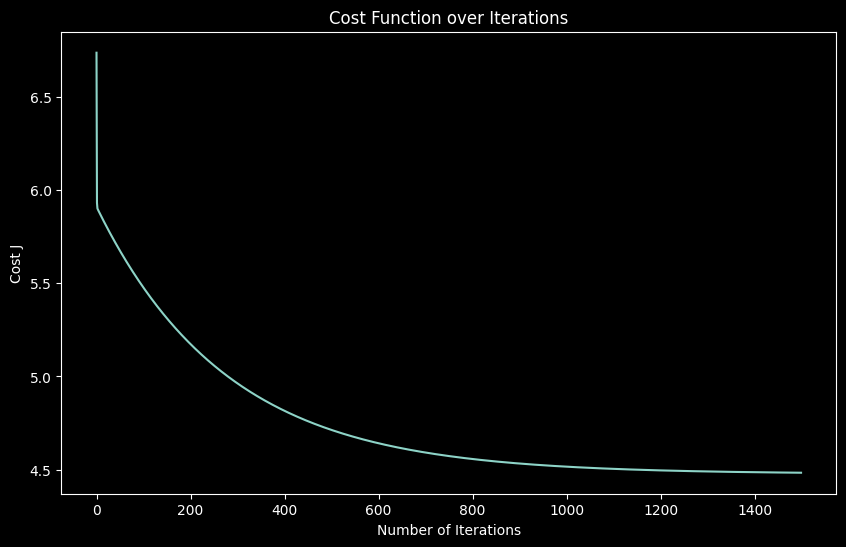

x为 35,000 , y为: 0.45
x为 70,000 , y为: 4.53


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 加载数据
data = np.loadtxt("data1.txt", delimiter=",")
X = data[:, 0]
y = data[:, 1]
m = len(y)  # 样本数量

# 为X添加一列，用于表示截距项
X = np.stack([np.ones(m), X], axis=1)


# 2. 定义模型和假设函数
# 假设函数 h(x) = theta[0] + theta[1] * x
def hypothesis(X, theta):
    return np.dot(X, theta)


# 3. 定义损失函数 (均方误差)
def compute_cost(X, y, theta):
    m = len(y)
    predictions = hypothesis(X, theta)
    sq_errors = (predictions - y) ** 2
    return 1 / (2 * m) * np.sum(sq_errors)


# 4. 编码实现梯度下降算法
def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    J_history = []  # 用来记录每次迭代的损失值

    for i in range(iterations):
        predictions = hypothesis(X, theta)
        errors = predictions - y

        # 计算梯度
        gradient = (1 / m) * np.dot(X.T, errors)

        # 更新参数
        theta = theta - alpha * gradient

        # 记录损失值
        J_history.append(compute_cost(X, y, theta))

    return theta, J_history


# 5. 初始化参数并开始训练
theta = np.zeros(2)  # 初始化 theta 为 [0, 0]
alpha = 0.01  # 学习率
iterations = 1500  # 迭代次数

theta_final, J_history = gradient_descent(X, y, theta, alpha, iterations)

print("通过梯度下降法得到的参数 theta:", theta_final)
print("最终损失值:", J_history[-1])


# --- 画图 ---

# 6. 数据散点图以及得到的直线
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 1], y, label="Training Data") # 训练数据
plt.plot(X[:, 1], hypothesis(X, theta_final), color="red", label="Linear Regression")
plt.title("Linear Regression Fit") # 线性回归拟合
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


# 7. 梯度下降过程中损失的变化图
plt.figure(figsize=(10, 6))
plt.plot(range(iterations), J_history)
plt.title("Cost Function over Iterations") # 迭代过程中损失函数的变化
plt.xlabel("Number of Iterations") # 迭代次数
plt.ylabel("Cost J") # 损失值 J
plt.show()


# 8. 基于训练得到的参数，进行预测
predict1 = np.dot([1, 3.5], theta_final) * 10000
print(f"x为 35,000 , y为: {predict1:,.2f}")

predict2 = np.dot([1, 7.0], theta_final) * 10000
print(f"x为 70,000 , y为: {predict2:,.2f}")